In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),                  # (1, 28, 28) → (784)
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        latent = self.encoder(x)
        out = self.decoder(latent)
        return out

In [ ]:
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
for epoch in range(epochs):
    for images, _ in loader:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
print("Training finished.\n")

Epoch [1/20], Loss: 0.0311
Epoch [2/20], Loss: 0.0227
Epoch [3/20], Loss: 0.0196
Epoch [4/20], Loss: 0.0163
Epoch [5/20], Loss: 0.0161
Epoch [6/20], Loss: 0.0168
Epoch [7/20], Loss: 0.0153
Epoch [8/20], Loss: 0.0151
Epoch [9/20], Loss: 0.0120
Epoch [10/20], Loss: 0.0139
Epoch [11/20], Loss: 0.0126
Epoch [12/20], Loss: 0.0121
Epoch [13/20], Loss: 0.0112
Epoch [14/20], Loss: 0.0108
Epoch [15/20], Loss: 0.0108
Epoch [16/20], Loss: 0.0111
Epoch [17/20], Loss: 0.0109
Epoch [18/20], Loss: 0.0110
Epoch [19/20], Loss: 0.0105
Epoch [20/20], Loss: 0.0100
Training finished.



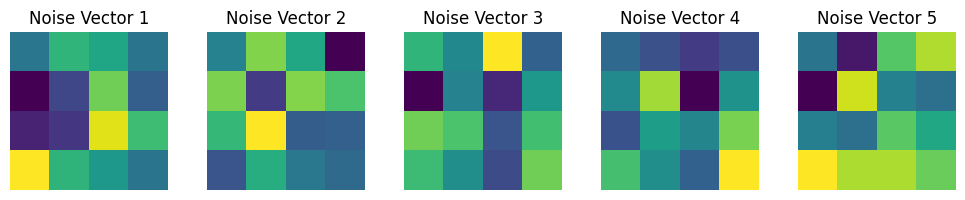

In [ ]:
noise_vectors = torch.normal(mean=5.0, std=1.0, size=(5, 16))
plt.figure(figsize=(10, 2))
for i in range(5):
    vector_image = noise_vectors[i].reshape(4, 4).cpu().numpy()
    plt.subplot(1, 5, i + 1)
    plt.imshow(vector_image)
    plt.title(f"Noise Vector {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

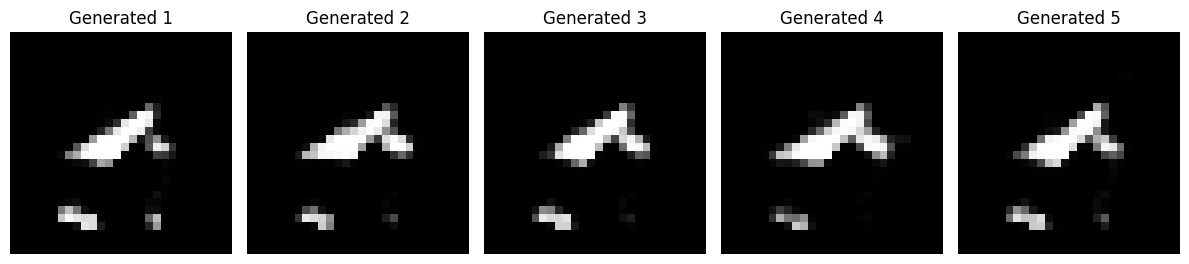

In [ ]:
noise_vectors = noise_vectors.to(next(model.parameters()).device)  # match device
with torch.no_grad():
    generated_images = model.decoder(noise_vectors).cpu()
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.title(f"Generated {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()